# Phase 1 : Analyse Exploratoire des Données (EDA) - Corporación Favorita
**Objectif :** Comprendre les données de ventes réelles de **Corporación Favorita** (2013-2017) pour anticiper les stocks. Cette analyse permet de voir comment les ventes évoluent et quels facteurs (ville, type de produit, promotions, jours fériés) influencent la demande.

**Note sur l'échantillon :** Nous analysons ici les 2 000 000 premières lignes (débutant en **janvier 2013**).

## 1. Chargement et Préparation
On prépare les bibliothèques nécessaires et on charge l'échantillon pour analyse.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('muted')

try:
    df_train = pd.read_csv('../data/train.csv', nrows=2000000)
    df_train['date'] = pd.to_datetime(df_train['date'])
    df_train = df_train.rename(columns={'store_nbr': 'store_id', 'item_nbr': 'item_id', 'unit_sales': 'sales'})
    df_train['sales'] = df_train['sales'].clip(lower=0)
    
    print(f"Données chargées : {df_train.shape} enregistrements.")
except FileNotFoundError:
    print("Fichier train.csv non trouvé.")

Données chargées : (2000000, 6) enregistrements.


## 2. Enrichissement des Données
On ajoute les informations sur les magasins, les articles et surtout les **jours fériés** (`holidays_events.csv`).

In [2]:
stores_df = pd.read_csv('../data/stores.csv')
items_df = pd.read_csv('../data/items.csv')
holidays_df = pd.read_csv('../data/holidays_events.csv')
holidays_df['date'] = pd.to_datetime(holidays_df['date'])

# Jointures de base
df_train = df_train.merge(stores_df[['store_nbr', 'city', 'state']], left_on='store_id', right_on='store_nbr', how='left').drop('store_nbr', axis=1)
df_train = df_train.merge(items_df[['item_nbr', 'family']], left_on='item_id', right_on='item_nbr', how='left').drop('item_nbr', axis=1)

# Marquage des jours fériés
df_train = df_train.merge(holidays_df[['date', 'type']], on='date', how='left')
df_train['is_holiday'] = df_train['type'].notna().astype(int)
df_train = df_train.drop('type', axis=1)

print("Données enrichies prêtes pour l'analyse.")

Données enrichies prêtes pour l'analyse.


## 3. Analyse de la Saisonnalité et des Événements

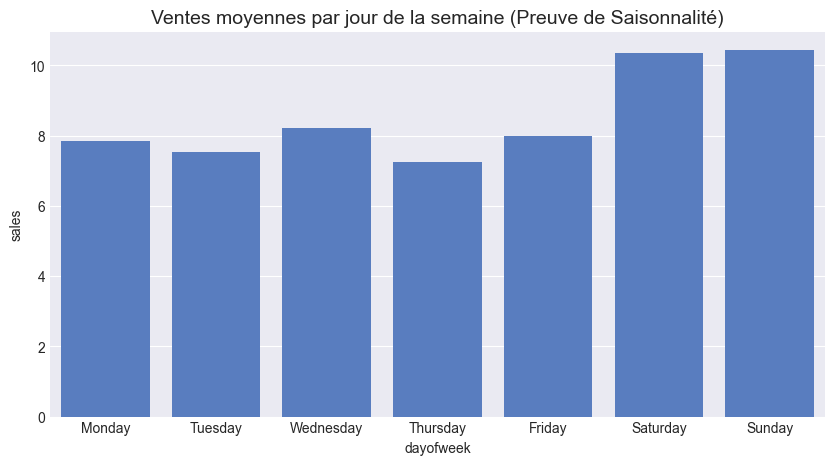

In [3]:
# 3.1. Saisonnalité hebdomadaire (Ventes par jour de la semaine)
df_train['dayofweek'] = df_train['date'].dt.day_name()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_train, x='dayofweek', y='sales', order=order, estimator=np.mean, ci=None)
plt.title('Ventes moyennes par jour de la semaine (Preuve de Saisonnalité)', fontsize=14)
plt.show()

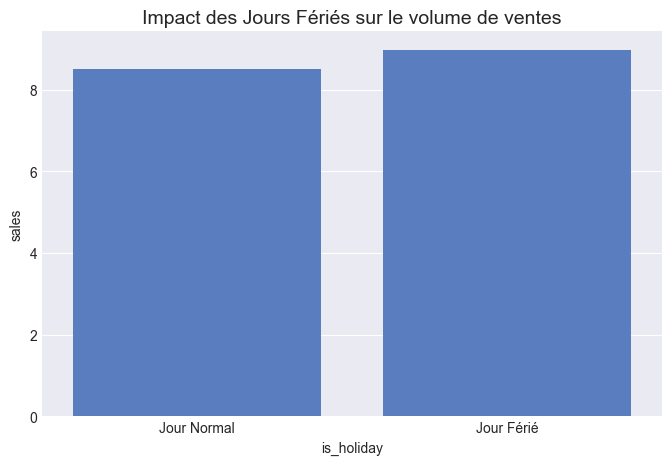

In [4]:
# 3.2. Impact des Jours Fériés
plt.figure(figsize=(8, 5))
sns.barplot(data=df_train, x='is_holiday', y='sales', estimator=np.mean, ci=None)
plt.xticks([0, 1], ['Jour Normal', 'Jour Férié'])
plt.title('Impact des Jours Fériés sur le volume de ventes', fontsize=14)
plt.show()

## 4. Conclusion : Que retenir pour notre projet d'IA ?

1.  **Saisonnalité Hebdomadaire :** On observe visuellement que les ventes augmentent significativement le week-end (Samedi/Dimanche). C'est pourquoi le modèle utilise le 'Day of Week' et les ventes 'il y a 7 jours'.
2.  **Impact des Jours Fériés :** Les jours fériés montrent une variation des ventes (souvent à la hausse pour certains produits). **C'est un facteur que nous devons intégrer à l'entraînement du modèle** pour éviter les ruptures de stock lors des événements spéciaux.
3.  **Choix Stratégique :** Le modèle XGBoost pourra apprendre que ces jours spécifiques nécessitent un approvisionnement plus agressif.

**En résumé :** L'analyse confirme que le temps (jours de la semaine) et les événements (fériés) sont des leviers majeurs de la demande chez Corporación Favorita.